<a href="https://colab.research.google.com/github/dandanakaka/DeepLearningLab/blob/main/DeepLearningLab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Font Setup and Library Imports

In [1]:
import subprocess
subprocess.run(['apt-get','install','-y','texlive-latex-extra','texlive-fonts-recommended','dvipng','cm-super'],capture_output=True)
import matplotlib
matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['font.serif']=['Computer Modern Roman']
matplotlib.rcParams['text.usetex']=True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron as SklearnPerceptron
import time
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load and Explore Dataset

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
cols = ['variance','skewness','curtosis','entropy','class']
df = pd.read_csv(url, header=None, names=cols)

print('=== Dataset Shape ===')
print(df.shape)
print('\n=== First 5 Rows ===')
print(df.head())
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Descriptive Statistics ===')
print(df.describe())
print('\n=== Class Distribution ===')
print(df['class'].value_counts())

=== Dataset Shape ===
(1372, 5)

=== First 5 Rows ===
   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

=== Missing Values ===
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

=== Descriptive Statistics ===
          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475    

## 3. Exploratory Data Analysis

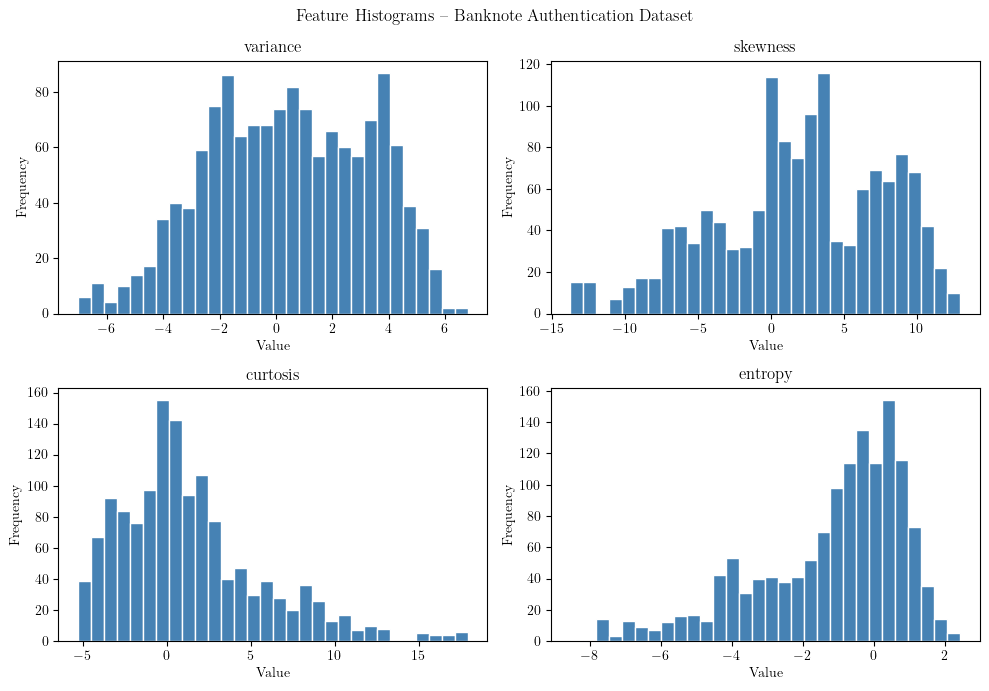

Plot 1 saved.


In [3]:
features = ['variance','skewness','curtosis','entropy']

# Feature Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.suptitle('Feature Histograms -- Banknote Authentication Dataset')
plt.tight_layout()
plt.savefig('plot1_histograms.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 1 saved.')

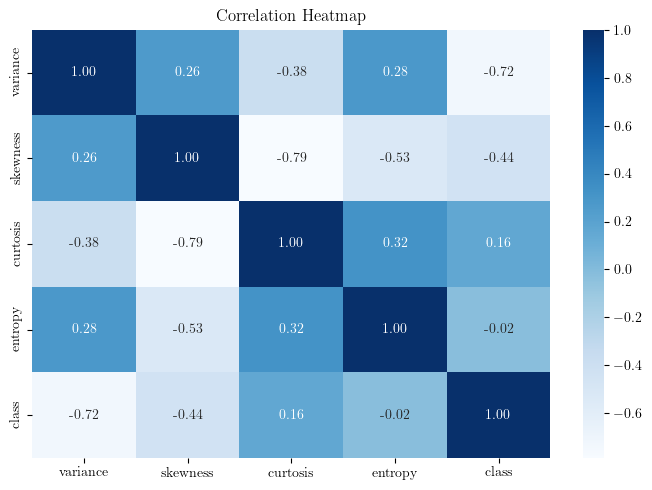

Plot 2 saved.


In [4]:
# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot2_correlation.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 2 saved.')

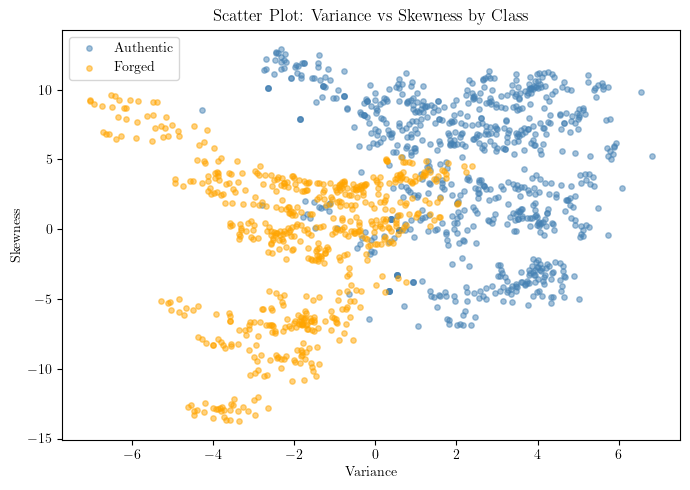

Plot 3 saved.


In [5]:
# Scatter Plot (variance vs skewness, coloured by class)
plt.figure(figsize=(7, 5))
for cls, colour, label in [(0,'steelblue','Authentic'),(1,'orange','Forged')]:
    mask = df['class'] == cls
    plt.scatter(df.loc[mask,'variance'], df.loc[mask,'skewness'],
                c=colour, label=label, alpha=0.5, s=15)
plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.title('Scatter Plot: Variance vs Skewness by Class')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 3 saved.')

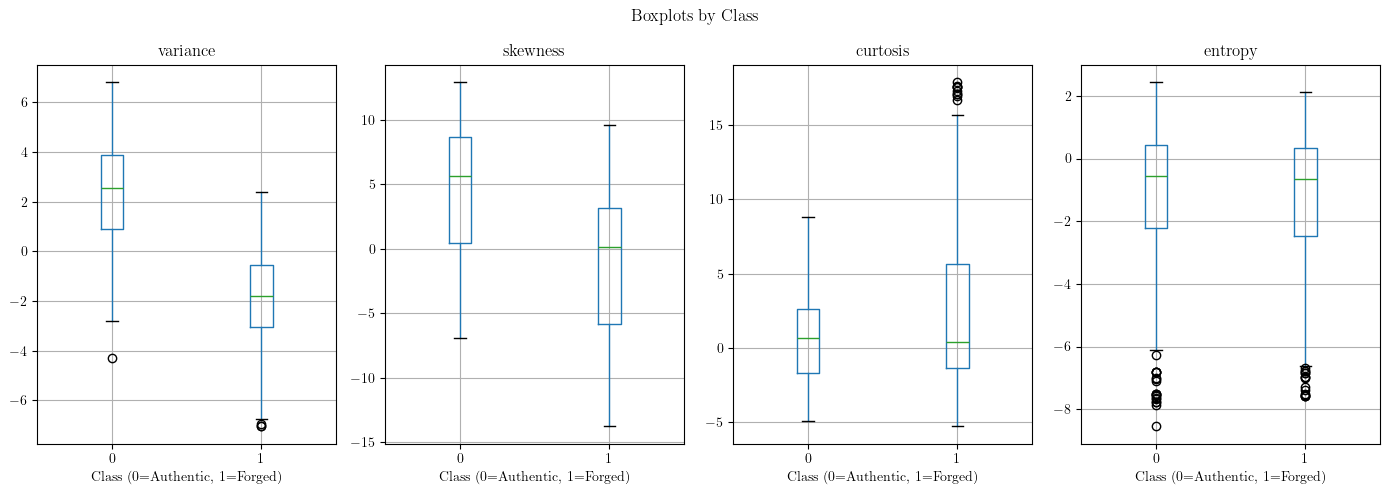

Plot 4 saved.


In [6]:
# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='class', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('Class (0=Authentic, 1=Forged)')
plt.suptitle('Boxplots by Class')
plt.tight_layout()
plt.savefig('plot4_boxplots.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 4 saved.')

## 4. Data Preprocessing

In [7]:
X = df[features].values
y = df['class'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 1097
Testing  samples : 275
Features         : 4


## 5. Single Layer Perceptron from Scratch

In [8]:
class SingleLayerPerceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50):
        self.lr     = learning_rate
        self.epochs = n_epochs
        self.w      = np.zeros(n_features)
        self.b      = 0.0
        self.errors_per_epoch = []
        self.weight_history   = []
        self.bias_history     = []

    def _step(self, z):
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        return self._step(np.dot(X, self.w) + self.b)

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_hat  = self._step(np.dot(xi, self.w) + self.b)
                delta  = self.lr * (yi - y_hat)
                self.w += delta * xi
                self.b += delta
                errors += int(delta != 0)
            self.errors_per_epoch.append(errors)
            self.weight_history.append(self.w.copy())
            self.bias_history.append(self.b)
            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f'Epoch {epoch+1:3d} | Errors: {errors:4d} | '
                      f'w={np.round(self.w,4)} | b={self.b:.4f}')

print('Perceptron class defined.')

Perceptron class defined.


## 6. Train Perceptron

In [9]:
slp = SingleLayerPerceptron(n_features=X_train.shape[1],
                             learning_rate=0.01, n_epochs=50)
start = time.time()
slp.fit(X_train, y_train)
train_time = time.time() - start

print(f'\nFinal Weights : {np.round(slp.w, 4)}')
print(f'Final Bias    : {slp.b:.4f}')
print(f'Training Time : {train_time:.3f}s')

Epoch   1 | Errors:   59 | w=[-0.068  -0.0938 -0.0678 -0.011 ] | b=-0.0300
Epoch  10 | Errors:   20 | w=[-0.1307 -0.1541 -0.125  -0.006 ] | b=-0.0600
Epoch  20 | Errors:   19 | w=[-0.1636 -0.1946 -0.1613 -0.0064] | b=-0.0700
Epoch  30 | Errors:   17 | w=[-0.1751 -0.2043 -0.1901 -0.0196] | b=-0.0800
Epoch  40 | Errors:   18 | w=[-0.1948 -0.2244 -0.1853 -0.0197] | b=-0.0900
Epoch  50 | Errors:   18 | w=[-0.1941 -0.2358 -0.2109 -0.0195] | b=-0.1000

Final Weights : [-0.1941 -0.2358 -0.2109 -0.0195]
Final Bias    : -0.1000
Training Time : 0.902s


## 7. Mandatory Plots -- Training Behaviour

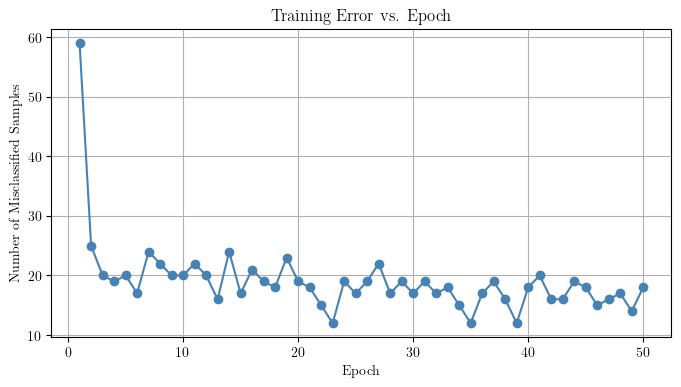

Plot 5 saved.


In [10]:
# Plot 5 -- Training Error vs Epoch
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(slp.errors_per_epoch)+1), slp.errors_per_epoch,
         marker='o', color='steelblue')
plt.title('Training Error vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Number of Misclassified Samples')
plt.grid(True)
plt.savefig('plot5_training_error.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 5 saved.')

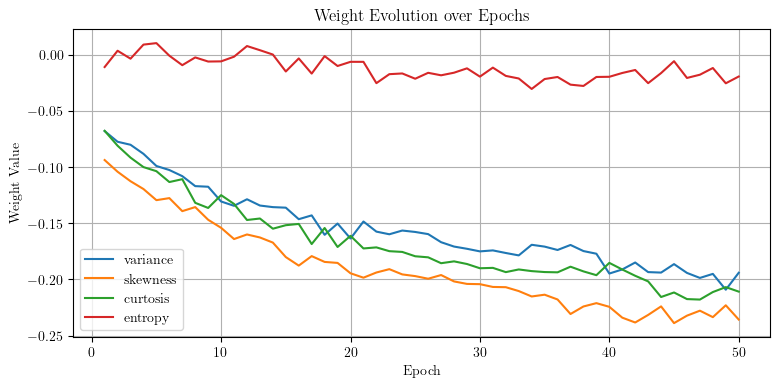

Plot 6 saved.


In [11]:
# Plot 6 -- Weight Evolution
weight_arr = np.array(slp.weight_history)
plt.figure(figsize=(9, 4))
for i, feat in enumerate(features):
    plt.plot(range(1, len(weight_arr)+1), weight_arr[:, i], label=feat)
plt.title('Weight Evolution over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Weight Value')
plt.legend()
plt.grid(True)
plt.savefig('plot6_weight_evolution.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 6 saved.')

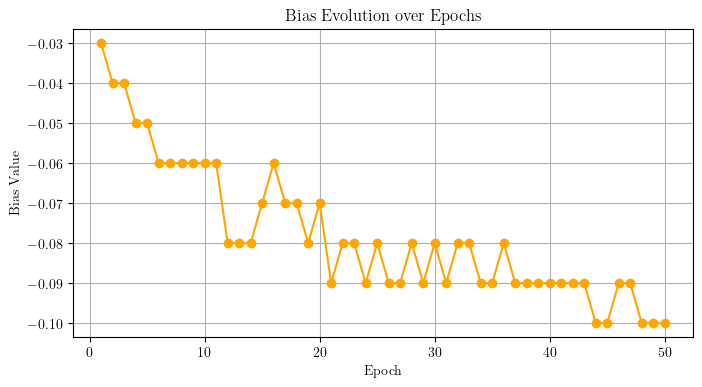

Plot 7 saved.


In [12]:
# Plot 7 -- Bias Evolution
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(slp.bias_history)+1), slp.bias_history,
         color='orange', marker='o')
plt.title('Bias Evolution over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Bias Value')
plt.grid(True)
plt.savefig('plot7_bias_evolution.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 7 saved.')

## 8. Model Evaluation

Accuracy  : 0.9855
Precision : 0.9683
Recall    : 1.0000
F1-score  : 0.9839

Confusion Matrix:
[[149   4]
 [  0 122]]


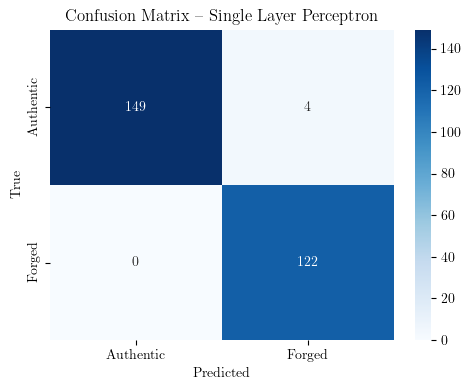

Plot 8 saved.


In [13]:
y_pred = slp.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')
print(f'\nConfusion Matrix:\n{cm}')

# Plot 8 -- Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic','Forged'],
            yticklabels=['Authentic','Forged'])
plt.title('Confusion Matrix -- Single Layer Perceptron')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('plot8_confusion_matrix.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 8 saved.')

## 9. Learning Rate Comparison (Plot 9)

Epoch   1 | Errors:   59 | w=[-0.0068 -0.0094 -0.0068 -0.0011] | b=-0.0030
Epoch  10 | Errors:   20 | w=[-0.0131 -0.0154 -0.0125 -0.0006] | b=-0.0060
Epoch  20 | Errors:   19 | w=[-0.0164 -0.0195 -0.0161 -0.0006] | b=-0.0070
Epoch  30 | Errors:   17 | w=[-0.0175 -0.0204 -0.019  -0.002 ] | b=-0.0080
Epoch  40 | Errors:   18 | w=[-0.0195 -0.0224 -0.0185 -0.002 ] | b=-0.0090
Epoch  50 | Errors:   18 | w=[-0.0194 -0.0236 -0.0211 -0.0019] | b=-0.0100
Epoch   1 | Errors:   59 | w=[-0.068  -0.0938 -0.0678 -0.011 ] | b=-0.0300
Epoch  10 | Errors:   20 | w=[-0.1307 -0.1541 -0.125  -0.006 ] | b=-0.0600
Epoch  20 | Errors:   19 | w=[-0.1636 -0.1946 -0.1613 -0.0064] | b=-0.0700
Epoch  30 | Errors:   17 | w=[-0.1751 -0.2043 -0.1901 -0.0196] | b=-0.0800
Epoch  40 | Errors:   18 | w=[-0.1948 -0.2244 -0.1853 -0.0197] | b=-0.0900
Epoch  50 | Errors:   18 | w=[-0.1941 -0.2358 -0.2109 -0.0195] | b=-0.1000
Epoch   1 | Errors:   59 | w=[-0.6803 -0.9381 -0.6782 -0.1104] | b=-0.3000
Epoch  10 | Errors:   20 

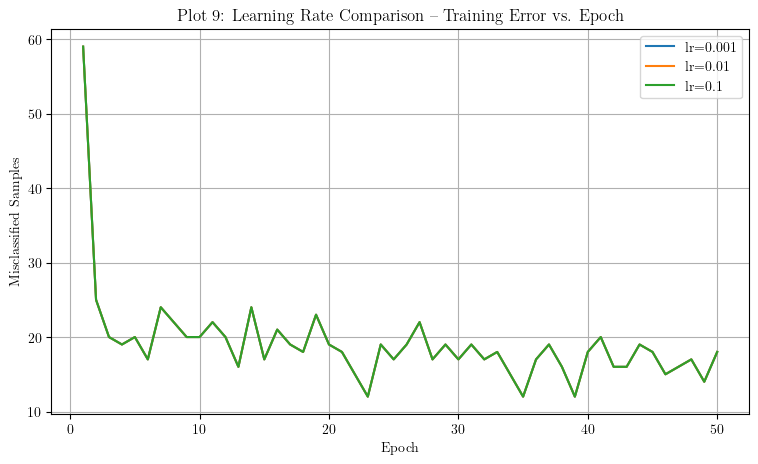


Test Accuracy by Learning Rate:
  lr=0.001: 0.9855
  lr=0.01: 0.9855
  lr=0.1: 0.9855
Plot 9 saved.


In [14]:
learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(9, 5))

lr_results = {}
for lr in learning_rates:
    m = SingleLayerPerceptron(n_features=X_train.shape[1],
                               learning_rate=lr, n_epochs=50)
    m.fit(X_train, y_train)
    plt.plot(range(1, 51), m.errors_per_epoch, label=f'lr={lr}')
    y_p = m.predict(X_test)
    lr_results[lr] = accuracy_score(y_test, y_p)

plt.title('Plot 9: Learning Rate Comparison -- Training Error vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Misclassified Samples')
plt.legend()
plt.grid(True)
plt.savefig('plot9_lr_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

print('\nTest Accuracy by Learning Rate:')
for lr, a in lr_results.items():
    print(f'  lr={lr}: {a:.4f}')
print('Plot 9 saved.')

## 10. Decision Boundary (Optional, Plot 10)

Epoch   1 | Errors:  196 | w=[-0.017  -0.0192] | b=0.0000
Epoch  10 | Errors:  182 | w=[-0.0202 -0.0192] | b=0.0000
Epoch  20 | Errors:  198 | w=[-0.0112 -0.0166] | b=0.0000
Epoch  30 | Errors:  196 | w=[-0.0138 -0.0211] | b=0.0000
Epoch  40 | Errors:  198 | w=[-0.0147 -0.0213] | b=0.0000
Epoch  50 | Errors:  192 | w=[-0.0203 -0.0319] | b=0.0000


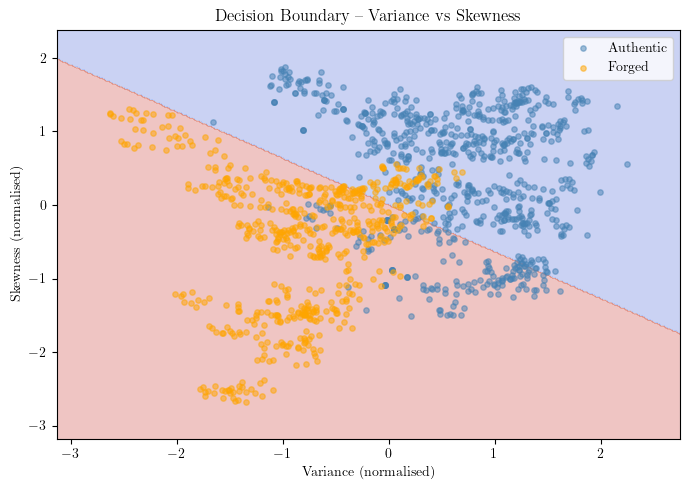

Plot 10 saved.


In [15]:
# Use first two features for 2D decision boundary
X_2d = X_scaled[:, :2]
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y)

slp_2d = SingleLayerPerceptron(n_features=2, learning_rate=0.01, n_epochs=50)
slp_2d.fit(X_tr2, y_tr2)

xx, yy = np.meshgrid(
    np.linspace(X_2d[:,0].min()-0.5, X_2d[:,0].max()+0.5, 300),
    np.linspace(X_2d[:,1].min()-0.5, X_2d[:,1].max()+0.5, 300))
Z = slp_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
for cls, colour, label in [(0,'steelblue','Authentic'),(1,'orange','Forged')]:
    mask = y == cls
    plt.scatter(X_2d[mask,0], X_2d[mask,1], c=colour, label=label, alpha=0.5, s=15)
plt.xlabel('Variance (normalised)')
plt.ylabel('Skewness (normalised)')
plt.title('Decision Boundary -- Variance vs Skewness')
plt.legend()
plt.tight_layout()
plt.savefig('plot10_decision_boundary.png', dpi=600, bbox_inches='tight')
plt.show()
print('Plot 10 saved.')

## 11. Scikit-learn Perceptron Comparison

In [16]:
sk_perc = SklearnPerceptron(eta0=0.01, max_iter=50, random_state=42)
sk_perc.fit(X_train, y_train)
y_sk = sk_perc.predict(X_test)

print('=== Comparison ===')
print(f'Scratch Perceptron Accuracy  : {acc:.4f}')
print(f'Sklearn Perceptron Accuracy  : {accuracy_score(y_test, y_sk):.4f}')

=== Comparison ===
Scratch Perceptron Accuracy  : 0.9855
Sklearn Perceptron Accuracy  : 0.9745


## 12. Final Summary

In [17]:
print('='*50)
print('FINAL RESULTS SUMMARY')
print('='*50)
print(f'Dataset Size     : {len(df)}')
print(f'Train/Test Split : 80/20')
print(f'Learning Rate    : 0.01')
print(f'Epochs           : 50')
print(f'Final Weights    : {np.round(slp.w, 4)}')
print(f'Final Bias       : {slp.b:.4f}')
print(f'Accuracy         : {acc:.4f}')
print(f'Precision        : {prec:.4f}')
print(f'Recall           : {rec:.4f}')
print(f'F1-score         : {f1:.4f}')
print(f'Training Time    : {train_time:.3f}s')

FINAL RESULTS SUMMARY
Dataset Size     : 1372
Train/Test Split : 80/20
Learning Rate    : 0.01
Epochs           : 50
Final Weights    : [-0.1941 -0.2358 -0.2109 -0.0195]
Final Bias       : -0.1000
Accuracy         : 0.9855
Precision        : 0.9683
Recall           : 1.0000
F1-score         : 0.9839
Training Time    : 0.902s
